# ChaosQKT with Psyduck: Quantum Chaos Simulation Tutorial

**Tutorial for Quantum Chaos Simulations using the Psyduck Framework**

This notebook demonstrates quantum chaos dynamics simulations using the **psyduck** library combined with custom helper functions from **ChaosQKT_pd_functions**.

The notebook uses ONLY:
- `psyduck` module (core framework)
- `psyduck.plotting` subfolder (Wigner visualization)
- `ChaosQKT_pd_functions` (custom chaos simulation functions)

NO functions from the `ChaosQKT` package (fitting, math_operations, plotting, utilities) are used.

## Section 1: Setup and Imports

Import psyduck and custom helper functions.

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Import psyduck library
from psyduck import Spin
from psyduck.plotting import wigner_plot_hammer

# Import custom ChaosQKT helper functions
import ChaosQKT_pd_functions as qkt

print("✓ Psyduck loaded successfully!")
print("✓ ChaosQKT_pd_functions loaded successfully!")
print(f"\nQuTiP version: {qt.__version__}")

✓ Psyduck loaded successfully!
✓ ChaosQKT_pd_functions loaded successfully!

QuTiP version: 5.2.3


## Section 2: Initialize Spin System

Create a Spin object using psyduck.

In [7]:
# Define spin quantum number
I = 7/2  # Spin-7/2 system (dimension 8)

# Create a Spin object using psyduck
nucleus = Spin(I=I)

print(f"✓ Created Spin system: I = {I}")
print(f"  Hilbert space dimension: {nucleus.dim}")

# Get spin operators from psyduck
Ix, Iy, Iz = nucleus.get_spin_operators()
print(f"✓ Spin operators created (shape: {Ix.shape})")

✓ Created Spin system: I = 3.5
  Hilbert space dimension: 8
✓ Spin operators created (shape: (8, 8))


## Section 3: Create Initial Spin-Coherent State

In [8]:
# Create a spin-coherent state at specific polar angles
theta = 0
phi = 0

psi_initial = qkt.initial_state(theta, phi, I)

print(f"✓ Created initial state at θ={theta:.3f}, φ={phi:.3f}")

# Calculate expectation values using ChaosQKT_pd_functions
exp_vals = qkt.qudit_exp(psi_initial, I)
print(f"\nExpectation values:")
print(f"  <Jx> = {exp_vals[0]:.4f}")
print(f"  <Jy> = {exp_vals[1]:.4f}")
print(f"  <Jz> = {exp_vals[2]:.4f}")

# Calculate entropy
entropy = qkt.qudit_linear_entropy(psi_initial, I)
print(f"\nLinear entropy: {entropy:.6f}")

✓ Created initial state at θ=0.000, φ=0.000

Expectation values:
  <Jx> = 0.0000
  <Jy> = 0.0000
  <Jz> = 3.5000

Linear entropy: 0.000000


### 3.1 Visualize Prepared State in Hammer Projection

Plot the Wigner function of the prepared spin-coherent state using Hammer projection.

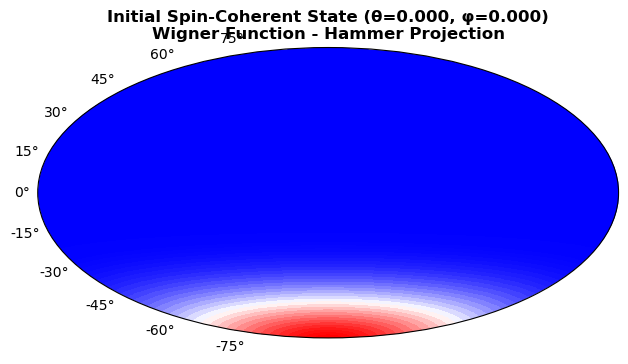

✓ Initial state visualized in Hammer projection
  The sharp peak indicates a well-defined spin-coherent state


In [9]:
# Visualize the prepared state using psyduck's wigner_plot_hammer
fig, ax = wigner_plot_hammer(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)

# Customize the plot
ax.set_title(
    f'Initial Spin-Coherent State (θ={theta:.3f}, φ={phi:.3f})\n'
    f'Wigner Function - Hammer Projection',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("✓ Initial state visualized in Hammer projection")
print(f"  The sharp peak indicates a well-defined spin-coherent state")

## Section 4: Run Kicked Dynamics Simulation

Simulate the quantum kicked top with nonlinear pulses, then visualize the evolution with an interactive slider showing Wigner functions in Hammer projection after each kick.

In [10]:
# Simulation parameters
tau = 1.0      # Free evolution time between kicks
kappa = 3.5*np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("Running kicked dynamics simulation...")
print(f"Parameters: tau={tau}, kappa={kappa}, N={N_kicks}, order={order}")

psi_list, overlap_list, entropy_list, exp_list = qkt.kicked_dynamics(
    psi_initial, tau, kappa, I, N=N_kicks, order=order, pulse_type='pulse'
)

print(f"✓ Simulation completed!")
print(f"  Generated {len(psi_list)} states")
print(f"\nChaos Metrics:")
print(f"  Initial entropy: {entropy_list[0]:.6f}")
print(f"  Final entropy: {entropy_list[-1]:.6f}")
print(f"  Entropy increase: {entropy_list[-1] - entropy_list[0]:.6f}")
print(f"  Final overlap: |<ψ(0)|ψ(T)>| = {abs(overlap_list[-1]):.6f}")

Running kicked dynamics simulation...
Parameters: tau=1.0, kappa=10.995574287564276, N=20, order=2
✓ Simulation completed!
  Generated 21 states

Chaos Metrics:
  Initial entropy: 0.000000
  Final entropy: 0.000000
  Entropy increase: 0.000000
  Final overlap: |<ψ(0)|ψ(T)>| = 0.125000


### 4.1 Interactive Wigner Function Visualization with Slider

Use the slider below to explore the Wigner function after each kick. The Hammer projection shows the phase space evolution throughout the simulation.

In [13]:

from ipywidgets import interact, IntSlider
from IPython.display import clear_output
def plot_wigner_evolution(kick_number):
    """Plot Wigner function for the state after a given kick number."""
    # Get state from psi_list
    state = psi_list[kick_number]
    # Plot using wigner_plot_hammer
    fig, ax = wigner_plot_hammer(
        state,
        n_theta=101,
        n_phi=201,
        cmap="bwr"
    )
    
    # Customize plot
    ax.set_title(
        f"Kick {kick_number}: Wigner Function Evolution\n"
        f"Entropy: {entropy_list[kick_number]:.6f} | "
        f"Overlap: {abs(overlap_list[kick_number]):.6f}",
        fontsize=12,
        fontweight="bold"
    )
    
    plt.tight_layout()
    plt.show()
    # clear_output(wait=True)
    # return fig
# Create interactive slider widget
print("\n" + "="*70)
print("Interactive Wigner Function Visualization")
print("="*70)
print(f"Slide to browse through all {len(psi_list)} states")
print(f"Observe phase space evolution from kick 0 to {N_kicks}")
print("="*70 + "\n")

interact(
    plot_wigner_evolution,
    kick_number=IntSlider(
        min=0,
        max=N_kicks,
        step=1,
        value=0,
        description="Kick:",
        continuous_update=True,
        layout={"width": "500px"}
    )
)


Interactive Wigner Function Visualization
Slide to browse through all 21 states
Observe phase space evolution from kick 0 to 20



interactive(children=(IntSlider(value=0, description='Kick:', layout=Layout(width='500px'), max=20), Output())…

<function __main__.plot_wigner_evolution(kick_number)>

## Section 5: Plot Evolution Metrics

Visualize the system dynamics across all kicks.

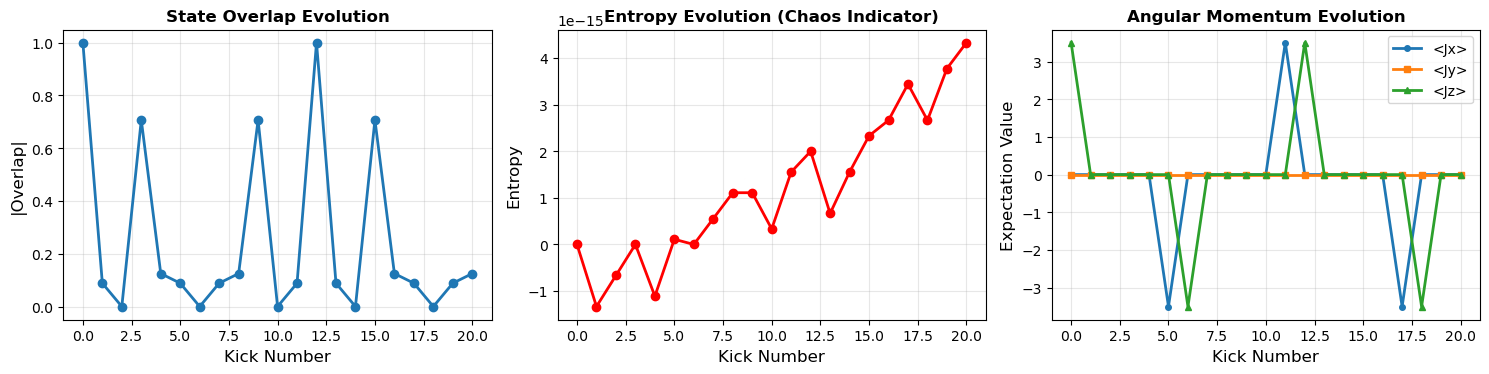

In [14]:
# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overlap evolution
axes[0].plot(range(len(overlap_list)), abs(np.array(overlap_list)), 'o-', linewidth=2, markersize=6, color='C0')
axes[0].set_xlabel('Kick Number', fontsize=12)
axes[0].set_ylabel('|Overlap|', fontsize=12)
axes[0].set_title('State Overlap Evolution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Entropy evolution
axes[1].plot(range(len(entropy_list)), entropy_list, 'o-', color='red', linewidth=2, markersize=6)
axes[1].set_xlabel('Kick Number', fontsize=12)
axes[1].set_ylabel('Entropy', fontsize=12)
axes[1].set_title('Entropy Evolution (Chaos Indicator)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Expectation values
exp_array = np.array(exp_list)
kicks = np.arange(len(exp_list))
axes[2].plot(kicks, exp_array[:, 0], 'o-', label='<Jx>', linewidth=2, markersize=4)
axes[2].plot(kicks, exp_array[:, 1], 's-', label='<Jy>', linewidth=2, markersize=4)
axes[2].plot(kicks, exp_array[:, 2], '^-', label='<Jz>', linewidth=2, markersize=4)
axes[2].set_xlabel('Kick Number', fontsize=12)
axes[2].set_ylabel('Expectation Value', fontsize=12)
axes[2].set_title('Angular Momentum Evolution', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Compare Initial and Final States

Visualize the phase space using Hammer projection from psyduck.plotting.

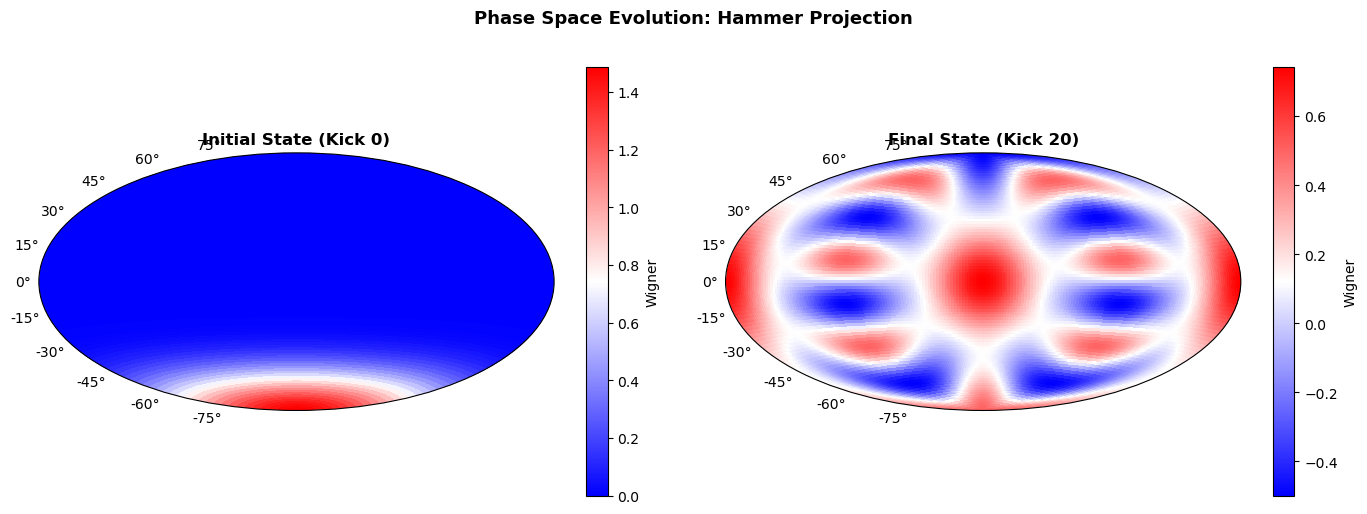

✓ Initial and final states compared
  Initial: Sharp peak indicating pure spin-coherent state
  Final: Spread distribution indicating decoherence/chaos


In [15]:
# Create side-by-side comparison using psyduck's wigner_plot_hammer
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': 'hammer'})

# Initial state
theta = np.linspace(0, np.pi, 101)
phi = np.linspace(-np.pi, np.pi, 201)
W_init, theta_mesh, phi_mesh = qt.spin_wigner(psi_initial, theta, phi)
pc1 = axes[0].pcolormesh(phi_mesh, theta_mesh - np.pi/2, W_init, cmap='bwr')
axes[0].set_xticklabels([])
axes[0].grid(False)
axes[0].set_title('Initial State (Kick 0)', fontsize=12, fontweight='bold')
fig.colorbar(pc1, ax=axes[0], label='Wigner')

# Final state
W_final, _, _ = qt.spin_wigner(psi_list[-1], theta, phi)
pc2 = axes[1].pcolormesh(phi_mesh, theta_mesh - np.pi/2, W_final, cmap='bwr')
axes[1].set_xticklabels([])
axes[1].grid(False)
axes[1].set_title(f'Final State (Kick {len(psi_list)-1})', fontsize=12, fontweight='bold')
fig.colorbar(pc2, ax=axes[1], label='Wigner')

plt.suptitle('Phase Space Evolution: Hammer Projection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Initial and final states compared")
print(f"  Initial: Sharp peak indicating pure spin-coherent state")
print(f"  Final: Spread distribution indicating decoherence/chaos")

## Section 7: Quick Reference

### Available Functions

#### From psyduck:
- `Spin(I=7/2)` - Create spin system
  - `.get_spin_operators()` - Get (Ix, Iy, Iz)
  - `.state` - Current quantum state
- `psyduck.plotting.wigner_plot_hammer()` - Hammer projection visualization

#### From ChaosQKT_pd_functions:
- `initial_state(theta, phi, j)` - Create spin-coherent state
- `qudit_exp(psi, j)` - Angular momentum expectation values
- `qudit_linear_entropy(psi, j)` - Linear entropy S
- `kicked_dynamics(psi_initial, tau, kappa, j, N, order, pulse_type)` - Main simulator
- `fit_exponential_decay()`, `fit_rabi_oscillation()`, `fit_gaussian()`, `fit_lorentzian()` - Data fitting
- `normalize_data()`, `smooth_data()`, `downsample_data()` - Utilities

### Key Points
✓ Section 3.1: Hammer projection visualization of prepared state

✓ Section 4.1: Interactive slider exploring all Wigner functions

✓ Uses ONLY psyduck and ChaosQKT_pd_functions

✓ NO imports from ChaosQKT (fitting, math_operations, plotting, utilities)

✓ All quantum simulations use ChaosQKT_pd_functions.kicked_dynamics()
